In [11]:
from npl.descriptors import ExtendedTopologicalFeaturesClassifier
from npl.monte_carlo.monte_carlo_etop import run_monte_carlo
from npl.core import Nanoparticle
from npl.calculators import EMTCalculator
from npl.calculators import BayesianRRCalculator
import matplotlib.pyplot as plt
from npl.visualize.visualize import plot_cummulative_success_rate, plot_learning_curves, plot_elemental_concentration_per_layer
from ase.visualize.plot import plot_atoms

In [12]:
def create_octahedron_training_set(n_particles, height, trunc, stoichiometry, descriptor_calculator):
    emt_calculator = EMTCalculator(fmax=0.2)

    training_set = []
    for i in range(n_particles):
        p = Nanoparticle()
        p.truncated_octahedron(height, trunc, stoichiometry)
        emt_calculator.compute_energy(p)
        descriptor_calculator.compute_feature_vector(p)
        training_set.append(p)

    return training_set

In [13]:
stoichiometry = {'Pd':0.33, 'Au' : 0.33, 'Cu' : 0.34}
etop = ExtendedTopologicalFeaturesClassifier(list(stoichiometry.keys()))

In [ ]:
training_set = create_octahedron_training_set(60, 5, 1, stoichiometry, etop)

In [ ]:
calculator = BayesianRRCalculator(etop.get_feature_key())
calculator.fit(training_set, 'EMT', validation_set=0.1)

Mean Absolute error 0.1834 meV/atom
Root Mean Square error 0.2328 meV/atom


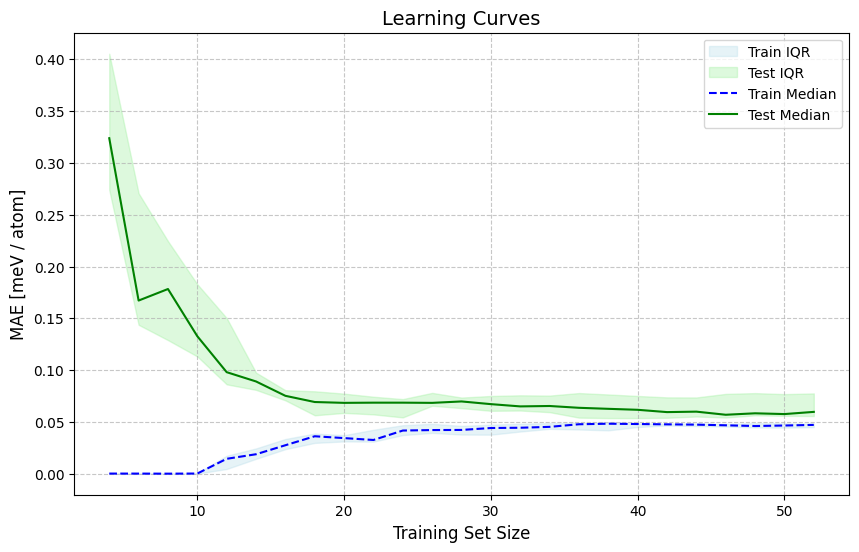

In [ ]:
X = [p.get_feature_vector(etop.get_feature_key()) for p in training_set]
y = [p.get_energy('EMT') for p in training_set]
n_atoms = training_set[0].get_n_atoms()
plot_learning_curves(X, y, n_atoms,
                     calculator.ridge, 
                     n_splits=10, train_sizes=range(4, int(len(training_set)*0.9), 2))

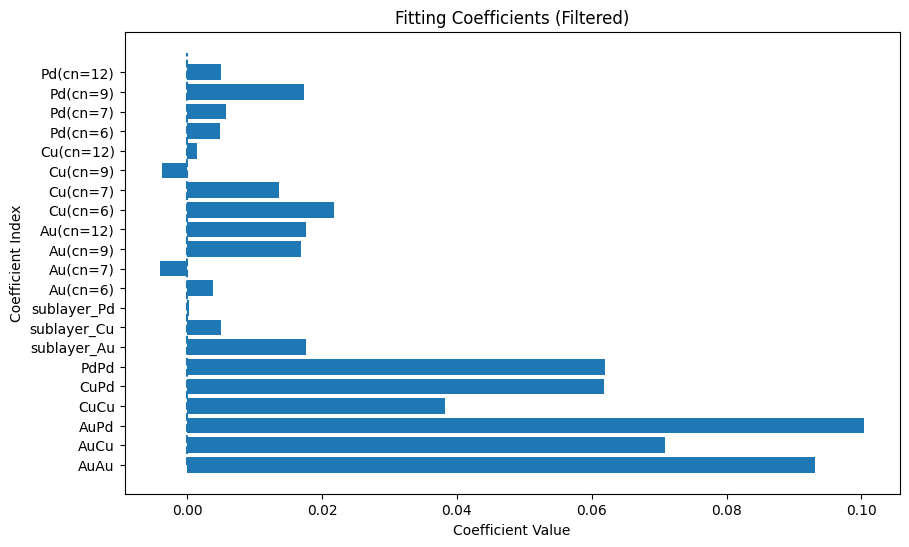

In [ ]:
coefficients = calculator.get_coefficients()
feature_names = etop.get_feature_labels()
# Filter coefficients that are not super close to 0
threshold = 1e-16
filtered_indices = [i for i, coef in enumerate(coefficients) if abs(coef) > threshold]
filtered_coefficients = [coefficients[i] for i in filtered_indices]
filtered_feature_names = [feature_names[i] for i in filtered_indices]

# Plot the filtered coefficients
plt.figure(figsize=(10, 6))
plt.barh(range(len(filtered_coefficients)), filtered_coefficients)
plt.vlines(0, 0, len(filtered_coefficients), linestyles='dashed')
plt.yticks(range(len(filtered_coefficients)), filtered_feature_names)
plt.ylabel('Coefficient Index')
plt.xlabel('Coefficient Value')
plt.title('Fitting Coefficients (Filtered)')
plt.show()

In [ ]:
def create_start_particle(height, trunc, stoichiometry):
    start_particle = Nanoparticle()
    start_particle.truncated_octahedron(height, trunc, stoichiometry)
    return start_particle

beta, max_steps = 300, 30000

steps_MC, energies_MC = [], []
for _ in range(10):
    start_particle = create_start_particle(6, 2, stoichiometry)
    [best_particle, accepted_energies] = run_monte_carlo(beta, max_steps, start_particle, calculator, etop)
    min_energy, min_step = min(accepted_energies, key=lambda x: x[0])
    energies_MC.append(min_energy)
    steps_MC.append(min_step)
    if min_energy <= min(energies_MC):
        global_minimum = best_particle

INFO - =====================================================
INFO - Monte Carlo simulation
INFO - =====================================================

INFO - Starting Monte Carlo simulation
INFO - Temperature: 300
INFO - Max steps: 30000
INFO - Starting energy: 39.061
INFO - Step: 2000
INFO - Lowest energy: 33.58383653641134
INFO - Step: 4000
INFO - Lowest energy: 33.370277820355824
INFO - Step: 6000
INFO - Lowest energy: 33.370277820355824
INFO - Step: 8000
INFO - Lowest energy: 33.246802785550045
INFO - Step: 10000
INFO - Lowest energy: 33.246802785550045
INFO - Step: 12000
INFO - Lowest energy: 33.246802785550045
INFO - Step: 14000
INFO - Lowest energy: 33.246802785550045
INFO - Step: 16000
INFO - Lowest energy: 33.246802785550045
INFO - Step: 18000
INFO - Lowest energy: 33.246802785550045
INFO - Step: 20000
INFO - Lowest energy: 33.246802785550045
INFO - Step: 22000
INFO - Lowest energy: 33.246802785550045
INFO - Step: 24000
INFO - Lowest energy: 33.246802785550045
INFO - Step: 2

KeyboardInterrupt: 

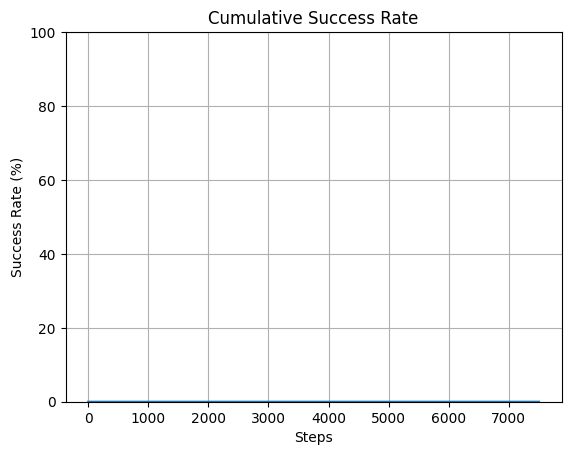

In [ ]:
plot_cummulative_success_rate(energies_MC, steps_MC)

(np.float64(0.0),
 np.float64(22.927459460971978),
 np.float64(0.0),
 np.float64(15.203999999999999))

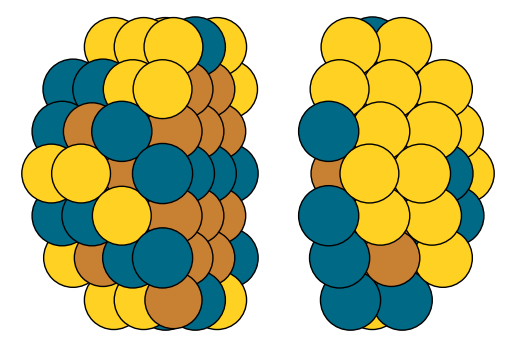

In [ ]:
atoms = global_minimum.get_ase_atoms()
atoms.center()
atoms1 = atoms[[a.index for a in atoms if a.position[2] < atoms.get_cell()[2][2]/2 +1.0]]
atoms2 = atoms[[a.index for a in atoms if a.position[2] > atoms.get_cell()[2][2]/2 +1.0]]
l = 3
atoms1.translate(( 0., 0.,-l))
atoms2.translate(( 0., 0.,l))
atoms = atoms1 + atoms2

plot_atoms(atoms, rotation=('0x,75y,0z'))
plt.axis('off')

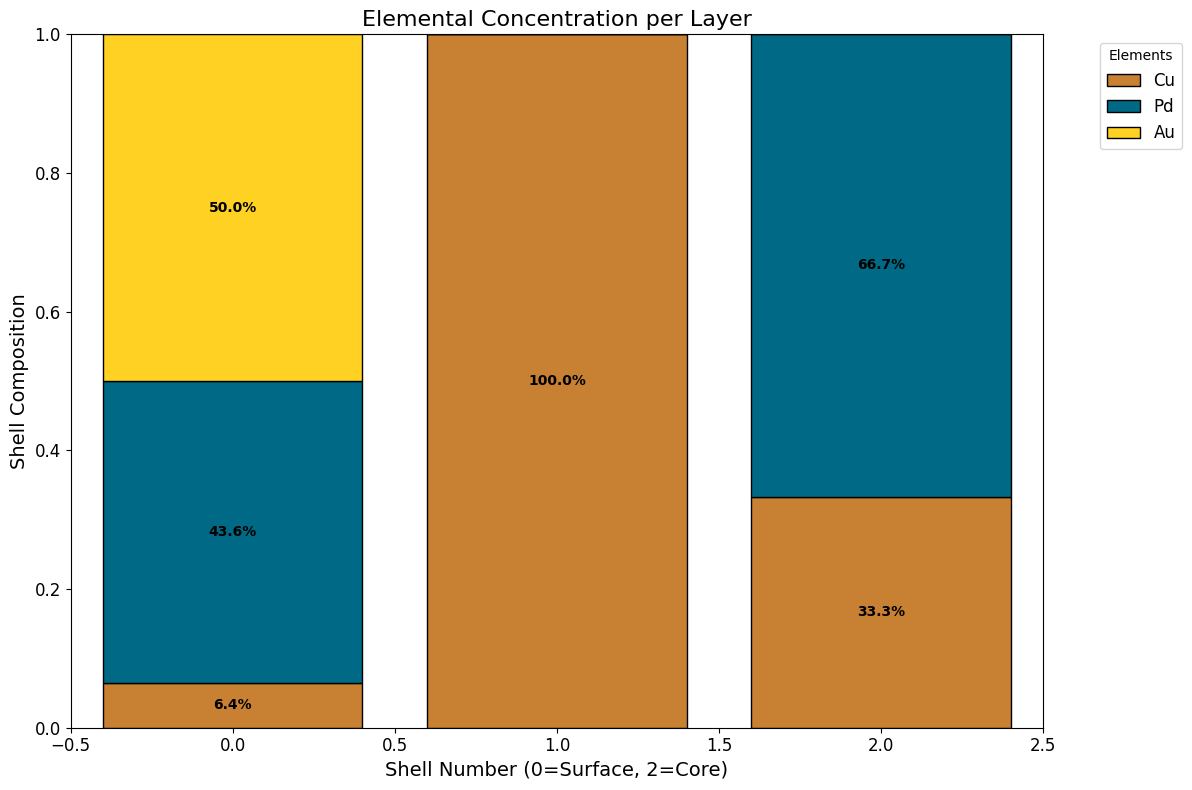

In [ ]:
plot_elemental_concentration_per_layer(global_minimum)

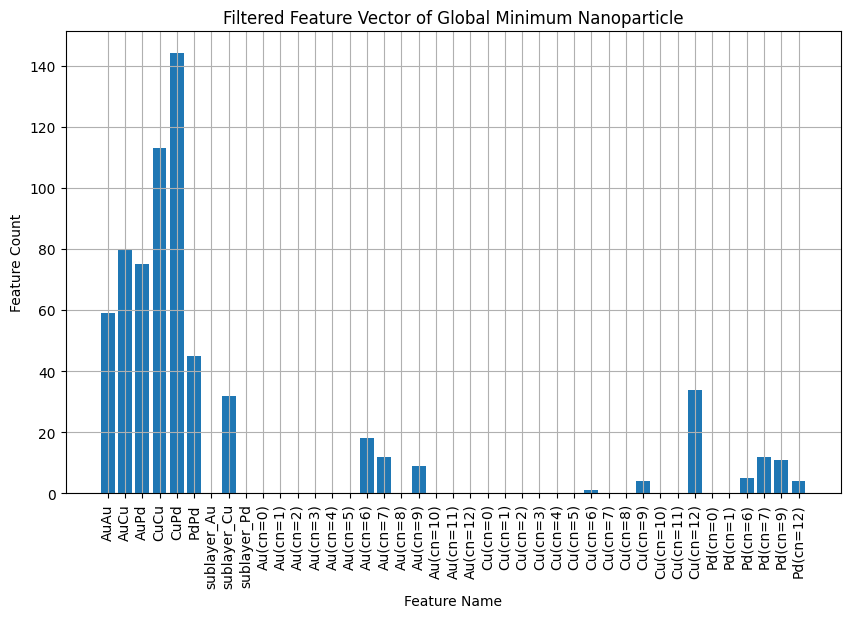

In [ ]:
# Filter the feature vector and feature names based on non-zero coefficients
feature_vector = global_minimum.get_feature_vector(etop.get_feature_key())
filtered_feature_vector = [feature_vector[i] for i in filtered_indices]
filtered_feature_names = [feature_names[i] for i in filtered_indices]

# Plot the filtered feature vector
plt.figure(figsize=(10, 6))
plt.bar(filtered_feature_names, filtered_feature_vector)
plt.xlabel('Feature Name')
plt.ylabel('Feature Count')
plt.title('Filtered Feature Vector of Global Minimum Nanoparticle')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

## Guided basin hopping vs Monte Carlo — runtime

The Metropolis MC above proposes *random* swaps. With a trained **linear** ETOP
model the same particle can be optimized with `run_basin_hopping(..., model="ETOP")`,
which proposes *guided* swaps (the most energy-lowering exchange per step) and reaches
a low-energy ordering in far fewer evaluations. Below we time both on the same particle
and the same `BayesianRRCalculator`.

In [ ]:
import time
from npl.optimization.basin_hopping.basin_hopping import run_basin_hopping

# Compare runtime of Metropolis MC vs ETOP guided basin hopping on the same
# trimetallic particle and the same (linear) BayesianRR energy model.
n_runs = 10

# --- Metropolis Monte Carlo (random swaps) ---
t0 = time.perf_counter()
energies_MC_timed = []
for _ in range(n_runs):
    start_particle = create_start_particle(6, 2, stoichiometry)
    best_particle, accepted = run_monte_carlo(beta, max_steps, start_particle, calculator, etop)
    energies_MC_timed.append(min(e for e, _ in accepted))
t_MC = time.perf_counter() - t0

# --- ETOP guided basin hopping (guided swaps) ---
# Same linear calculator; environment_energies is unused for ETOP (pass None).
t0 = time.perf_counter()
energies_BH = []
for _ in range(n_runs):
    start_particle = create_start_particle(6, 2, stoichiometry)
    best_particle, lowest_energies, _ = run_basin_hopping(
        start_particle, calculator, None,
        n_hopping_attempts=20, n_hops=5,
        local_feature_classifier=etop, model="ETOP")
    energies_BH.append(lowest_energies[-1][0])
t_BH = time.perf_counter() - t0

print(f"Monte Carlo       : {t_MC:7.2f} s  ({t_MC / n_runs:.2f} s/run)  best E = {min(energies_MC_timed):.3f}")
print(f"ETOP basin hopping: {t_BH:7.2f} s  ({t_BH / n_runs:.2f} s/run)  best E = {min(energies_BH):.3f}")
print(f"Speed-up          : {t_MC / t_BH:.1f}x")

INFO - =====================================================
INFO - Monte Carlo simulation
INFO - =====================================================

INFO - Starting Monte Carlo simulation
INFO - Temperature: 300
INFO - Max steps: 30000
INFO - Starting energy: 39.045
INFO - Step: 2000
INFO - Lowest energy: 33.5222828571144
INFO - Step: 4000
INFO - Lowest energy: 33.5222828571144
INFO - Step: 6000
INFO - Lowest energy: 33.363283249706434
INFO - Step: 8000
INFO - Lowest energy: 33.363283249706434
INFO - Step: 10000
INFO - Lowest energy: 33.363283249706434
INFO - Step: 12000
INFO - Lowest energy: 33.363283249706434
INFO - Step: 14000
INFO - Lowest energy: 33.31039503192318
INFO - Step: 16000
INFO - Lowest energy: 33.31039503192318
INFO - Step: 18000
INFO - Lowest energy: 33.31039503192318
INFO - Step: 20000
INFO - Lowest energy: 33.30587881679081
INFO - Step: 22000
INFO - Lowest energy: 33.30587881679081
INFO - Step: 24000
INFO - Lowest energy: 33.30587881679081
INFO - Step: 26000
INFO

KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(5, 4))
plt.bar(['Monte Carlo', 'ETOP basin hopping'], [t_MC, t_BH],
        color=['tab:gray', 'tab:blue'])
plt.ylabel('Wall-clock time (s)')
plt.title(f'Runtime for {n_runs} ordering optimizations')
plt.show()

NameError: name 't_MC' is not defined

<Figure size 500x400 with 0 Axes>